In [18]:
# bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd


In [19]:
#dados

# dados genericos
X = [0.5, 1.0, 2.5, 2.5, 6.5, 8.0, 7.0, 9.0]
y = [4.0, 7.0, 4.2, 6.5, 2.2, 2.45, 3.0, 2.5]

# kaggle : Student Study Hours

#df = pd.read_csv("archive/score_updated.csv")

#X = df['Hours'].values
#y = df['Scores'].value


In [20]:
# regressão linear simples

# declarando variaveis
lr = 0.01 # lr : taxa de aprendizado
# vê criterios dps para definir w0,w1 iniciais
w0 = 0.1
w1 = 0.1

# hipotese: y* = w0+w1*x
def y_hat(x, w0, w1):
    return w0+ w1*x

In [21]:
# plot dos pontos e regressão
def plot_line(X,y,w0,w1):
    x_values = [i for i in range(int(min(X))-1, int(max(X))+2)]
    y_values = [y_hat(x,w0,w1) for x in x_values]

    plt.plot(x_values,y_values, 'r')
    plt.plot(X,y,'bo')

In [22]:
# função do erro medio quadrado
def mse(X, y, w0, w1):
    cost = 0
    m = float(len(X))

    for i in range(0,len(X)):
        cost += (y_hat(X[i],w0,w1)-y[i])**2

    return cost/m

In [23]:
# função do gradiente descendente
def gradient_descent_step(w0,w1,X,y,lr):
    erro_w0=0
    erro_w1=0
    m = len(X)

    for i in range(0,m): 
        erro_w0 += y_hat(X[i],w0,w1) - y[i]
        erro_w1 += (y_hat(X[i],w0,w1) - y[i]) * X[i]
    
    new_w0 = w0 - lr * (1/m) * erro_w0
    new_w1 = w1 - lr * (1/m) * erro_w1

    return new_w0, new_w1

In [24]:
# looping do gradiente descendente

epoch = 3000

def gradient_descent(w0,w1,X,y,lr,epoch):
    w0_hist = np.zeros(epoch)
    w1_hist = np.zeros(epoch)
    cost = np.zeros(epoch)

    cost_anterior = float('inf') # declarada para evitar erro na primeira iteração do looping

    for i in range(epoch):
        w0,w1 = gradient_descent_step(w0,w1,X,y,lr)

        cost_atual = mse(X,y,w0,w1)
        cost[i] = cost_atual
        w0_hist[i]=w0
        w1_hist[i]=w1

        if abs(cost_atual - cost_anterior) < 1e-6: # 'ponto' de convergencia
            cost = cost[:i+1]
            w0_hist = w0_hist[:i+1]
            w1_hist = w1_hist[:i+1]
            break

        cost_anterior = cost_atual

    return w0,w1,cost,w0_hist, w1_hist
    

Text(0.5, 1.0, 'MSE vs Epoch')

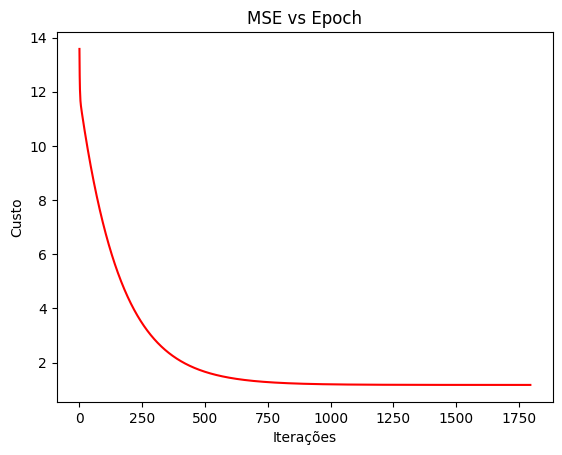

In [25]:
# plot do custo

w0, w1, cost, w0_hist, w1_hist = gradient_descent(w0, w1, X, y, lr, epoch)

fig, ax = plt.subplots()
ax.plot(np.arange(len(cost)), cost, 'r')
ax.set_xlabel('Iterações')
ax.set_ylabel('Custo')
ax.set_title("MSE vs Epoch")

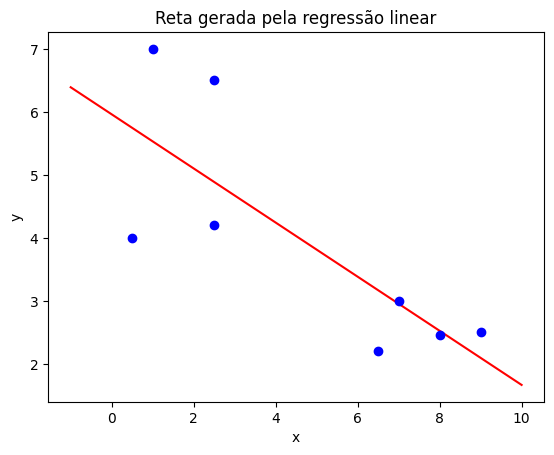

In [26]:
# plot da hipotese
plot_line(X,y,w0,w1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Reta gerada pela regressão linear')
plt.show()

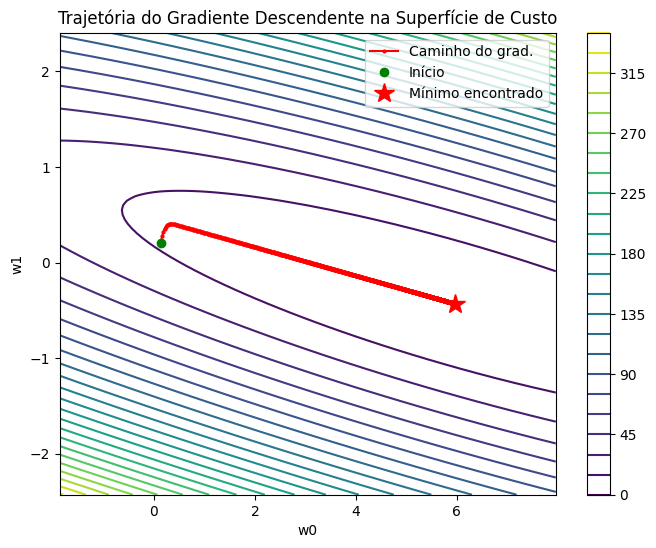

In [27]:
# malha de valores de w0 e w1 ao redor da trajetória
w0_range = np.linspace(min(w0_hist)-2, max(w0_hist)+2, 100)
w1_range = np.linspace(min(w1_hist)-2, max(w1_hist)+2, 100)
W0, W1 = np.meshgrid(w0_range, w1_range)

Z = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        Z[i, j] = mse(X, y, W0[i, j], W1[i, j])

fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contour(W0, W1, Z, levels=30, cmap='viridis')
ax.plot(w0_hist, w1_hist, 'r.-', markersize=4, label='Caminho do grad.')
ax.plot(w0_hist[0], w1_hist[0], 'go', label='Início')
ax.plot(w0_hist[-1], w1_hist[-1], 'r*', markersize=15, label='Mínimo encontrado')
ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.set_title('Trajetória do Gradiente Descendente na Superfície de Custo')
ax.legend()
fig.colorbar(cp)
plt.show()

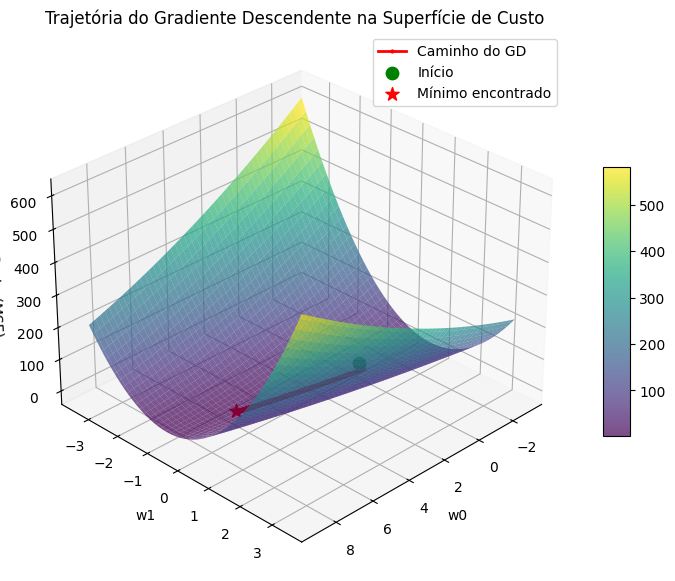

In [28]:
from mpl_toolkits.mplot3d import Axes3D

# reaproveitando o histórico de w0, w1 e custo do gradient_descent

w0_final, w1_final, cost, w0_hist, w1_hist = gradient_descent(0.1, 0.1, X, y, lr, epoch)

# malha de valores de w0 e w1 ao redor da trajetória encontrada
w0_range = np.linspace(min(w0_hist)-3, max(w0_hist)+3, 100)
w1_range = np.linspace(min(w1_hist)-3, max(w1_hist)+3, 100)
W0, W1 = np.meshgrid(w0_range, w1_range)

Z = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        Z[i, j] = mse(X, y, W0[i, j], W1[i, j])

# custo em cada ponto da trajetória (para plotar a linha na altura correta da superfície)
cost_hist = np.array([mse(X, y, w0_hist[i], w1_hist[i]) for i in range(len(w0_hist))])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# superfície de custo
surf = ax.plot_surface(W0, W1, Z, cmap='viridis', alpha=0.7, edgecolor='none')

# trajetória do gradiente descendente, levemente acima da superfície para ficar visível
ax.plot(w0_hist, w1_hist, cost_hist, 'r.-', markersize=4, linewidth=2, label='Caminho do GD')
ax.scatter(w0_hist[0], w1_hist[0], cost_hist[0], color='green', s=80, label='Início')
ax.scatter(w0_hist[-1], w1_hist[-1], cost_hist[-1], color='red', s=100, marker='*', label='Mínimo encontrado')

ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.set_zlabel('Custo (MSE)')
ax.set_title('Trajetória do Gradiente Descendente na Superfície de Custo')
ax.view_init(elev=30, azim=45)  # ajuste o ângulo de visualização
fig.colorbar(surf, shrink=0.5, aspect=10)
ax.legend()

plt.show()